In [339]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from abc import ABC, abstractmethod
import numpy as np
from sklearn.metrics import classification_report, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
import ast 

In [340]:
df_movies = pd.read_csv('movies_metadata.csv', delimiter=',', decimal='.', engine='python')
df_ratings = pd.read_csv('ratings_small.csv', delimiter=',', decimal='.')

df_movies['id'] = pd.to_numeric(df_movies['id'], errors='coerce')
df_movies = df_movies.dropna(subset=['id'])
df_movies['id'] = df_movies['id'].astype(int)

df_ratings['movieId'] = pd.to_numeric(df_ratings['movieId'], errors='coerce')
df_ratings = df_ratings.dropna(subset=['movieId'])
df_ratings['movieId'] = df_ratings['movieId'].astype(int)


cols_to_drop = [ 'imdb_id', 'original_title', 'tagline', 'poster_path', 
                'homepage', 'belongs_to_collection', 'production_companies', 
                'production_countries', 'status', 'video', 'original_language','adult']
X = df_movies.drop(columns=[c for c in cols_to_drop if c in df_movies.columns], errors='ignore')

#Жанры
def parse_genres(x):
    try:
        if isinstance(x, str):
            g = ast.literal_eval(x)
            return [i['name'] for i in g] if isinstance(g, list) else []
    except:
        pass
    return []

X['genre_list'] = X['genres'].apply(parse_genres)

all_genres = [genre for sublist in X['genre_list'] for genre in sublist]
top_genres = pd.Series(all_genres).value_counts().head(10).index.tolist()
for g in top_genres:
    X[f'genre_{g}'] = X['genre_list'].apply(lambda x: 1 if g in x else 0)

X = X.drop(columns=['genres', 'genre_list'])

#Языки
def parse_languages(x):
    try:
        if isinstance(x, str):
            l = ast.literal_eval(x)
            return [i['name'] for i in l] if isinstance(l, list) else []
    except:
        pass
    return []

X['lang_list'] = X['spoken_languages'].apply(parse_languages)
X['num_languages'] = X['lang_list'].apply(len)

top_langs = pd.Series([lang for sublist in X['lang_list'] for lang in sublist]).value_counts().head(3).index.tolist()
for lang in top_langs:
    X[f'lang_{lang}'] = X['lang_list'].apply(lambda x: 1 if lang in x else 0)

X = X.drop(columns=['spoken_languages', 'lang_list'])

#Год выпуска
X['release_date'] = pd.to_datetime(X['release_date'], errors='coerce')
X['release_year'] = X['release_date'].dt.year
X = X.drop(columns=['release_date'])

#Описание
X['overview'] = X['overview'].fillna('')
tfidf = TfidfVectorizer(max_features=10, stop_words='english')
df_text = tfidf.fit_transform(X['overview'])
feature_names = tfidf.get_feature_names_out()
X_text = pd.DataFrame(
    df_text.toarray(), 
    columns=[f'word_{name}' for name in feature_names]
)
X = X.drop(columns=['overview'])


X = pd.concat([X, X_text], axis=1)
X = X.fillna(X.mean(numeric_only=True)).dropna()
X = X.drop(columns = ['id', 'title','word_film'])



In [341]:
feature_names = X.columns.tolist()
X_scaled = StandardScaler().fit_transform(X)

X = pd.DataFrame(X_scaled, columns=feature_names)


print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")
print(feature_names)

Признаков: 30, Объектов: 45459
['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count', 'genre_Drama', 'genre_Comedy', 'genre_Thriller', 'genre_Romance', 'genre_Action', 'genre_Horror', 'genre_Crime', 'genre_Documentary', 'genre_Adventure', 'genre_Science Fiction', 'num_languages', 'lang_English', 'lang_Français', 'lang_Deutsch', 'release_year', 'word_family', 'word_life', 'word_love', 'word_man', 'word_new', 'word_old', 'word_story', 'word_world', 'word_young']


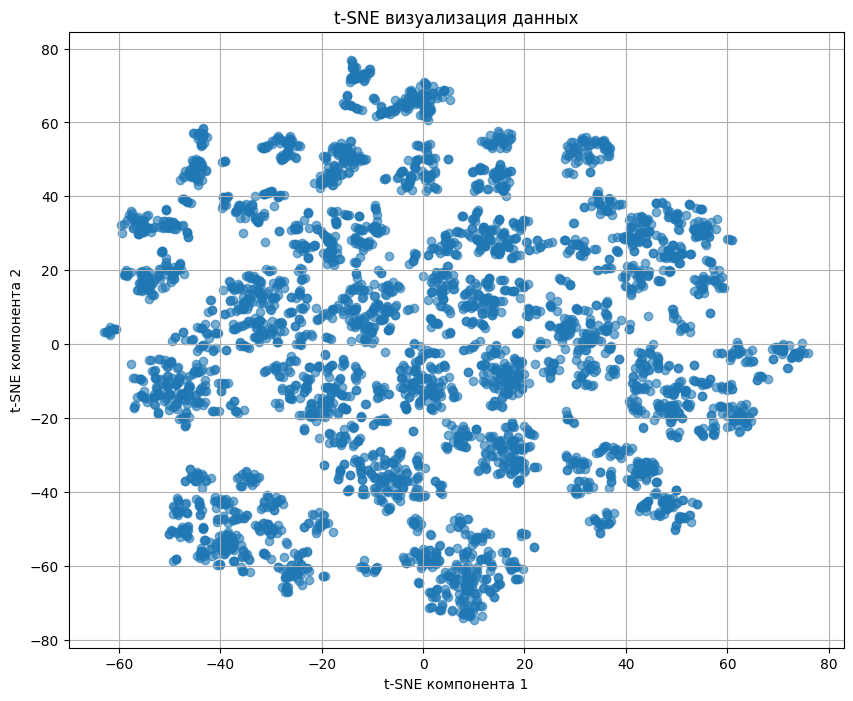

In [342]:
X_sample = X.sample(frac=0.1, random_state=42)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)  

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6)
plt.title('t-SNE визуализация данных')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(True)
plt.show()

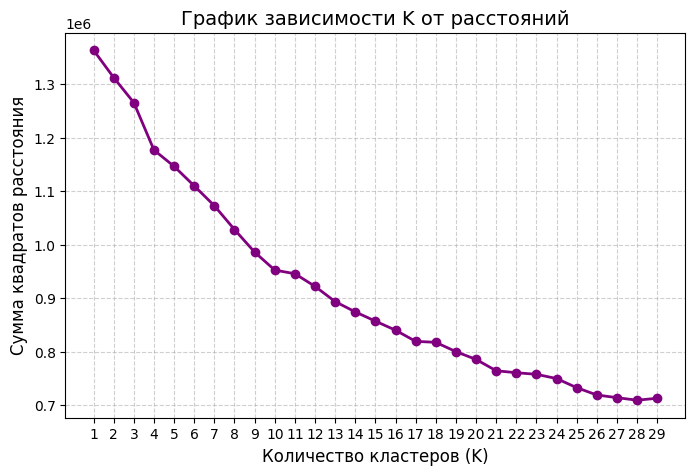

In [343]:
mean_distances = []
k_range = range(1, 30)  

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X)
    mean_distances.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, mean_distances, marker='o', color='purple', linestyle='-', linewidth=2)
plt.xlabel('Количество кластеров (K)', fontsize=12)
plt.ylabel('Сумма квадратов расстояния', fontsize=12)
plt.title('График зависимости K от расстояний', fontsize=14)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [344]:
kmeans = KMeans(n_clusters=10
, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X)

labels_kmeans = kmeans.labels_

score = kmeans.score(X_sample)
print(f"Score: {score:.2f}")
for i in range(10):
    print(f"Кластер {i}: {np.sum(labels_kmeans==i)} объектов")


Score: -102923.37
Кластер 0: 2490 объектов
Кластер 1: 2317 объектов
Кластер 2: 2710 объектов
Кластер 3: 2796 объектов
Кластер 4: 3605 объектов
Кластер 5: 2410 объектов
Кластер 6: 574 объектов
Кластер 7: 3351 объектов
Кластер 8: 22059 объектов
Кластер 9: 3147 объектов


In [345]:
def analyze_cluster_features(X, labels, feature_names=None, n_top=10):
    if feature_names is None:
        feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
    
    df = pd.DataFrame(X, columns=feature_names)
    df['cluster'] = labels
    
    if -1 in labels:
        df = df[df['cluster'] != -1]
        print(f"Удалено шумовых точек: {np.sum(labels == -1)}")
    
    clusters = sorted(df['cluster'].unique())
    n_clusters = len(clusters)
    
    print(f"АНАЛИЗ ПРИЗНАКОВ ДЛЯ {n_clusters} КЛАСТЕРОВ")
    
    X_clean = df.drop('cluster', axis=1).values
    y_clean = df['cluster'].values
    
    f_scores, p_values = f_classif(X_clean, y_clean)
    
    feature_importance = pd.DataFrame({
        'Признак': feature_names,
        'F-статистика': f_scores,
        'p-значение': p_values
    }).sort_values('F-статистика', ascending=False)
    
    print("ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ (ANOVA F-тест):")
    print(feature_importance.head(n_top).to_string(index=False))
    
    plt.figure(figsize=(12, 6))
    top_features = feature_importance.head(n_top)
    plt.barh(top_features['Признак'], top_features['F-статистика'], color='skyblue')
    plt.xlabel('F-статистика')
    plt.title('Топ признаков, разделяющих кластеры')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    cluster_means = df.groupby('cluster').mean()
    
    cluster_means_norm = (cluster_means - cluster_means.mean()) / cluster_means.std()
    
    plt.figure(figsize=(14, max(6, n_clusters * 0.6)))
    sns.heatmap(
        cluster_means_norm[feature_importance.head(n_top)['Признак'].tolist()],
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        cbar_kws={'label': 'Отклонение от среднего (в std)'}
    )
    plt.title('Средние значения топ-признаков по кластерам')
    plt.xlabel('Признаки')
    plt.ylabel('Кластер')
    plt.tight_layout()
    plt.show()
    
    global_mean = df.drop('cluster', axis=1).mean()
    
    print("ОПИСАНИЕ КАЖДОГО КЛАСТЕРА:")
    
    for cluster in clusters:
        size = np.sum(df['cluster'] == cluster)
        cluster_mean = cluster_means.loc[cluster]
        deviation = cluster_mean - global_mean
        
        top_high = deviation.nlargest(3)
        top_low = deviation.nsmallest(3)
        
        print(f"КЛАСТЕР {cluster} (n={size}, {size/len(df)*100:.1f}%)")
        
        if not top_high.empty:
            print("  ВЫШЕ СРЕДНЕГО:")
            for feat, val in top_high.items():
                print(f"    {feat}: +{val:.3f}")
        
        if not top_low.empty:
            print("  НИЖЕ СРЕДНЕГО:")
            for feat, val in top_low.items():
                print(f"    {feat}: {val:.3f}")
    
    return feature_importance, cluster_means

АНАЛИЗ ПРИЗНАКОВ ДЛЯ 10 КЛАСТЕРОВ
ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ (ANOVA F-тест):
              Признак  F-статистика    p-значение
         lang_Deutsch  89032.170682  0.000000e+00
    genre_Documentary  53790.347218  0.000000e+00
genre_Science Fiction  44092.775509  0.000000e+00
          genre_Crime  16602.139904  0.000000e+00
             word_old  16452.684704  0.000000e+00
      genre_Adventure  12644.875646  0.000000e+00
         genre_Horror  12294.669519  0.000000e+00
        lang_Français  10435.951403  0.000000e+00
              revenue   6952.216411  0.000000e+00
           vote_count   6394.197519  0.000000e+00
               budget   5002.170083  0.000000e+00
        num_languages   1250.941725  0.000000e+00
           popularity   1093.034419  0.000000e+00
       genre_Thriller    774.168768  0.000000e+00
         genre_Action    750.127216  0.000000e+00
          genre_Drama    746.279219  0.000000e+00
         genre_Comedy    309.048904  0.000000e+00
         lang_English   

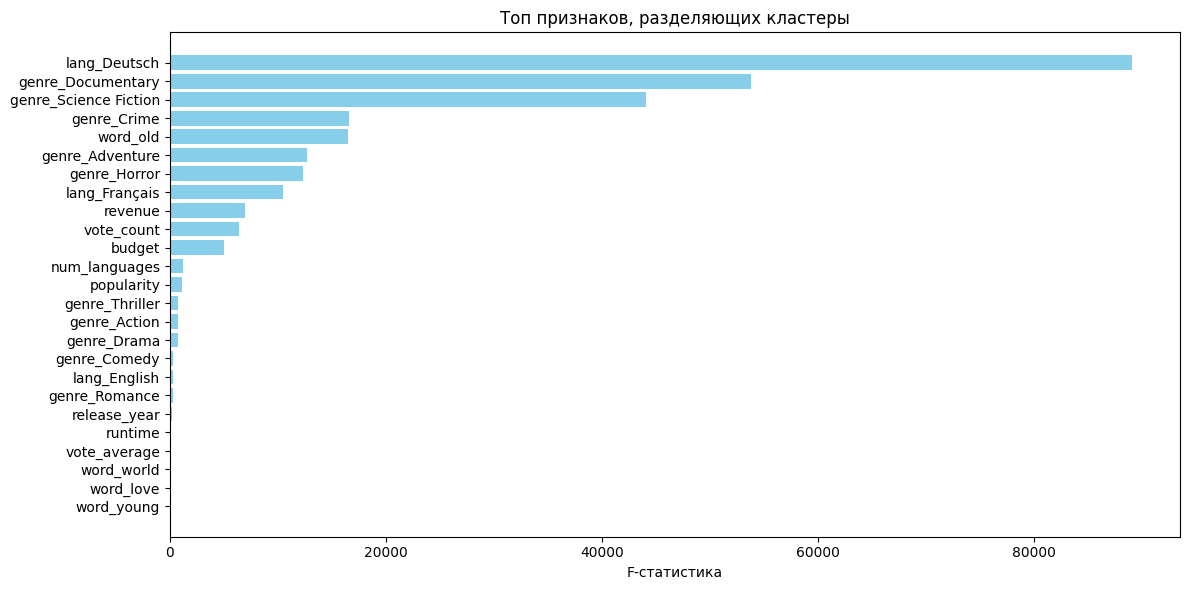

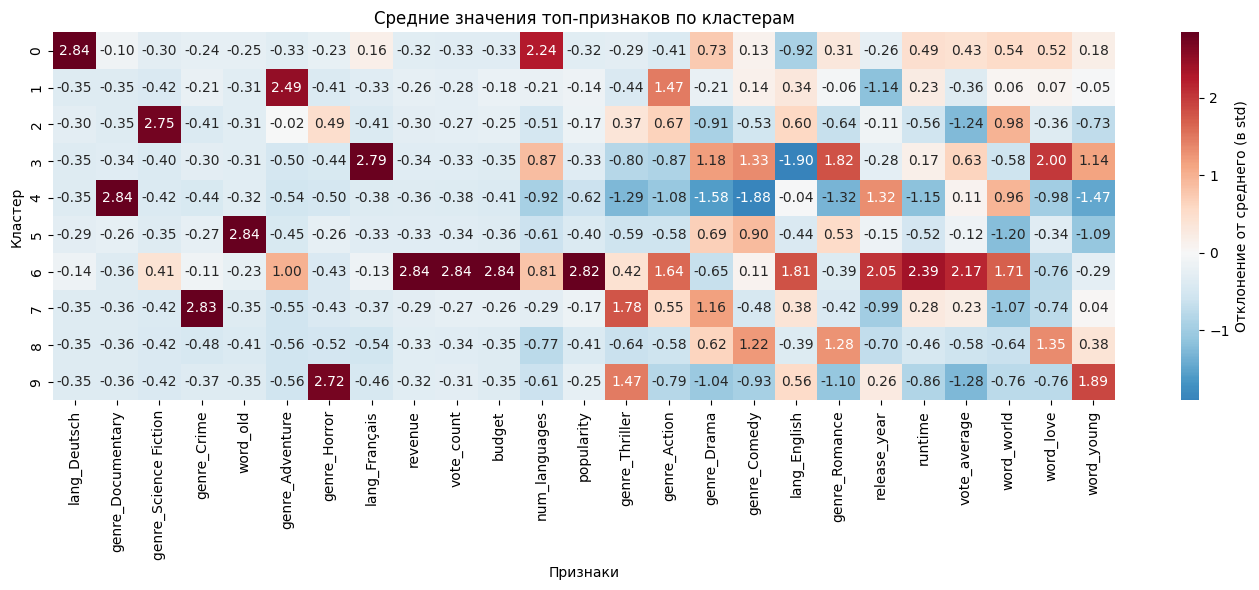

ОПИСАНИЕ КАЖДОГО КЛАСТЕРА:
КЛАСТЕР 0 (n=2490, 5.5%)
  ВЫШЕ СРЕДНЕГО:
    lang_Deutsch: +4.038
    num_languages: +1.522
    lang_Français: +0.410
  НИЖЕ СРЕДНЕГО:
    lang_English: -0.247
    genre_Science Fiction: -0.112
    revenue: -0.094
КЛАСТЕР 1 (n=2317, 5.1%)
  ВЫШЕ СРЕДНЕГО:
    genre_Adventure: +3.465
    genre_Action: +0.986
    budget: +0.217
  НИЖЕ СРЕДНЕГО:
    genre_Documentary: -0.291
    genre_Science Fiction: -0.268
    lang_Deutsch: -0.240
КЛАСТЕР 2 (n=2710, 6.0%)
  ВЫШЕ СРЕДНЕГО:
    genre_Science Fiction: +3.731
    genre_Horror: +0.687
    genre_Action: +0.554
  НИЖЕ СРЕДНЕГО:
    genre_Drama: -0.509
    genre_Documentary: -0.296
    genre_Romance: -0.251
КЛАСТЕР 3 (n=2796, 6.2%)
  ВЫШЕ СРЕДНЕГО:
    lang_Français: +3.135
    num_languages: +0.731
    genre_Drama: +0.398
  НИЖЕ СРЕДНЕГО:
    lang_English: -0.607
    genre_Documentary: -0.280
    genre_Action: -0.279
КЛАСТЕР 4 (n=3605, 7.9%)
  ВЫШЕ СРЕДНЕГО:
    genre_Documentary: +3.250
    release_year: +0.452
   

In [346]:
feature_names = X.columns.tolist()


importance_kmeans, means_kmeans = analyze_cluster_features(
    X,           
    labels_kmeans,  
    feature_names,
    n_top=25
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5684\3711541818.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5684\3711541818.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5684\3711541818.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5684\3711541818.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5684\3711541818.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Us

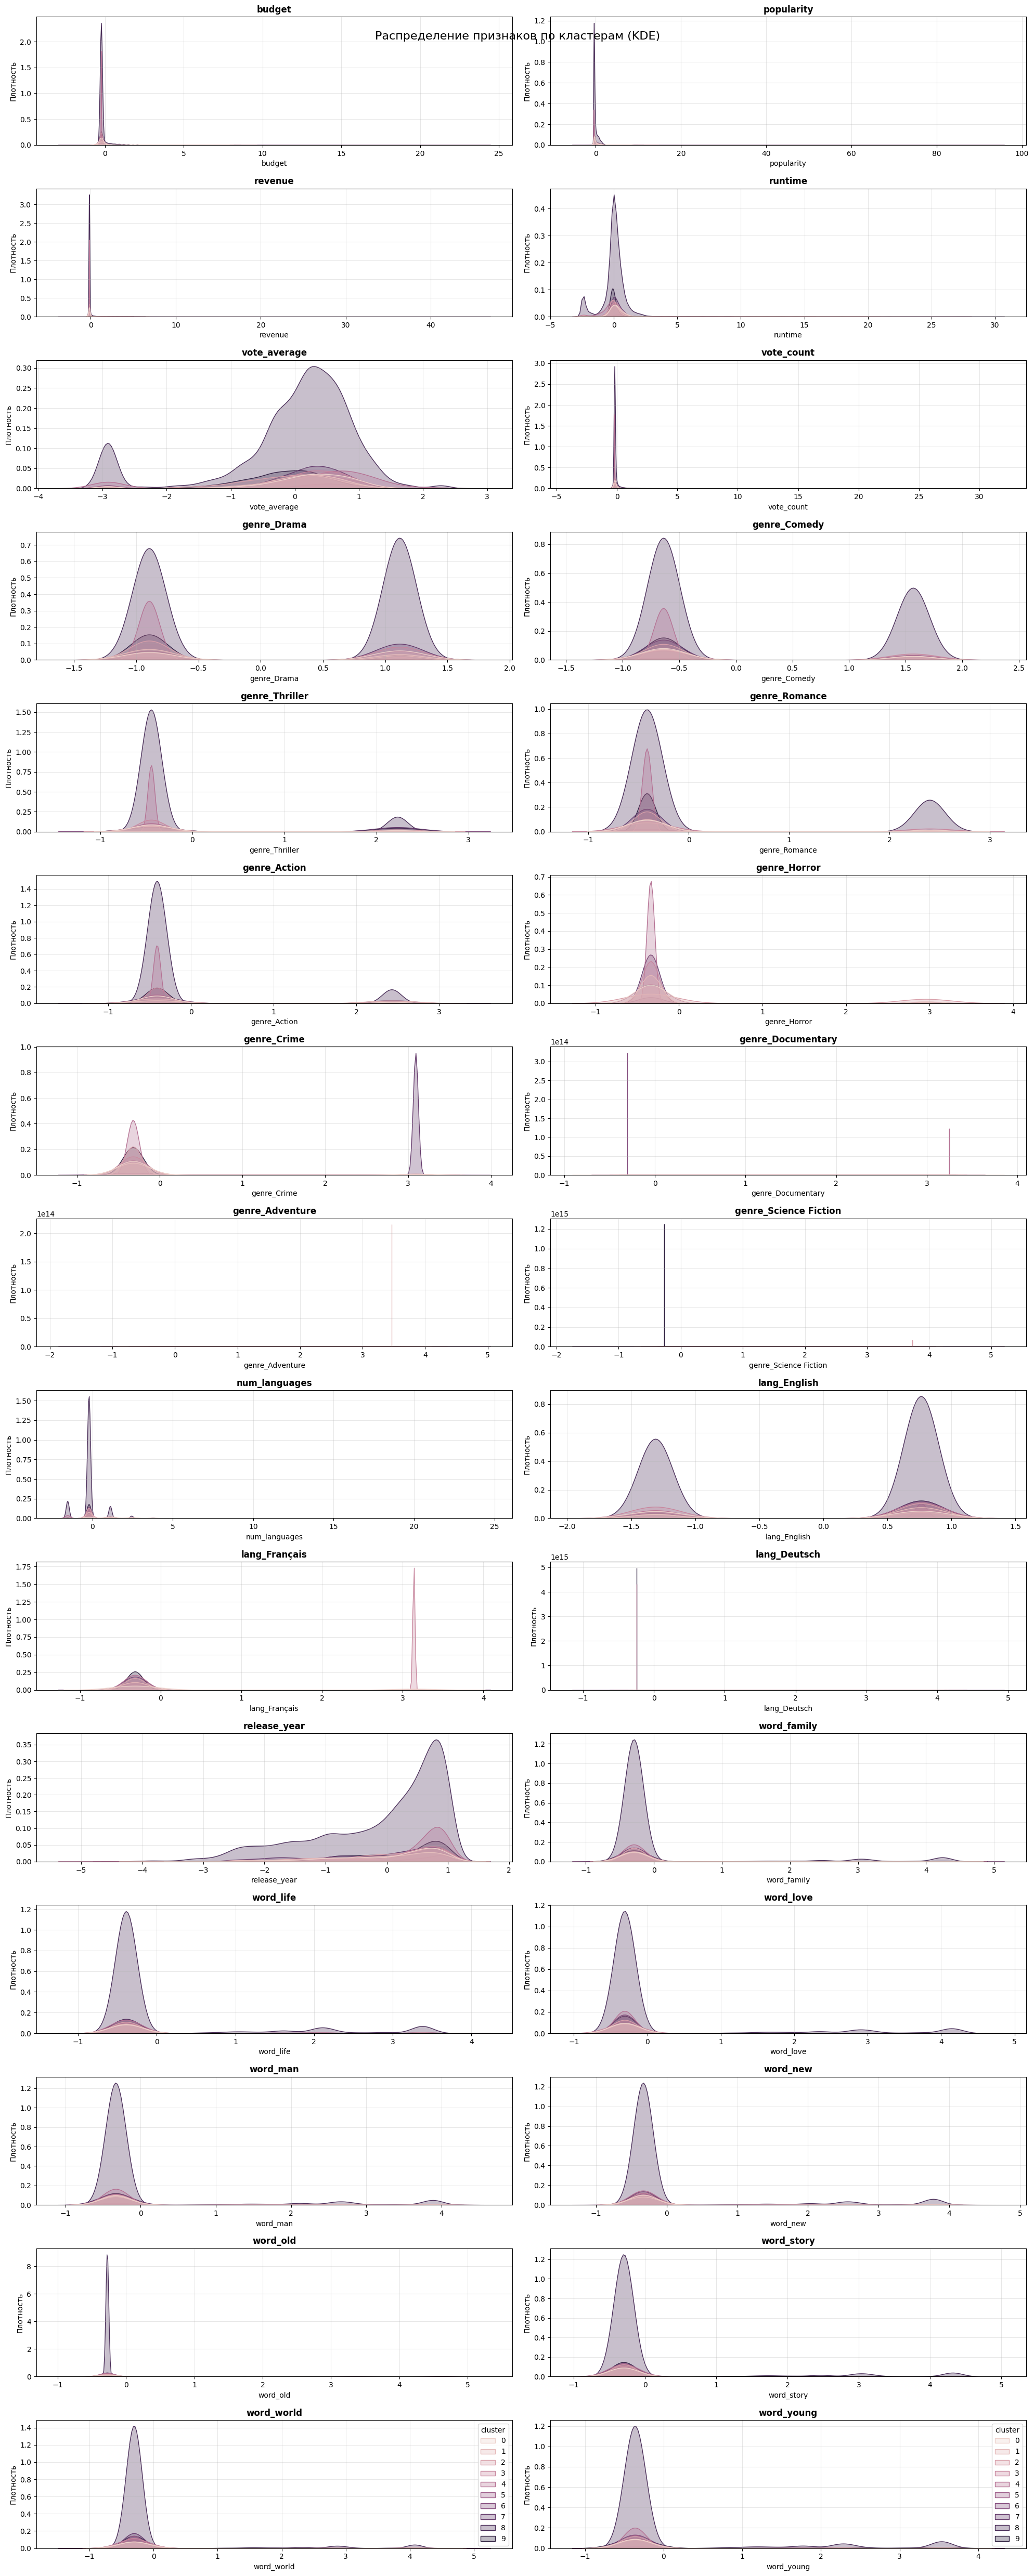

In [347]:
fig, axes = plt.subplots(15, 2, figsize=(20, 50))

X['cluster'] = labels_kmeans
    


for i, feature in enumerate(feature_names):
    row = i // 2
    col = i % 2

    sns.kdeplot(
        data=X,
        x=feature,
        hue='cluster',
        fill=True,
        alpha=0.3,
        ax=axes[row, col]
    )
    axes[row, col].set_title(feature, fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Плотность')
    axes[row, col].grid(True, alpha=0.3)

    if i < len(feature_names) - 2:
        axes[row, col].legend_.remove()

plt.suptitle('Распределение признаков по кластерам (KDE)', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
X['id']= df_movies['id'].astype('Int64')
X['title']= df_movies['title']

X


,budget,popularity,revenue,runtime,vote_average,vote_count,genre_Drama,genre_Comedy,genre_Thriller,genre_Romance,...,word_love,word_man,word_new,word_old,word_story,word_world,word_young,cluster,id,title
0,1.479228,3.168049,5.632394,-0.342790,1.081895,10.797865,-0.89678,1.564790,-0.448859,-0.417041,...,-0.309912,-0.330626,-0.332579,-0.276225,-0.300344,-0.305254,-0.364883,6,862,Toy Story
1,3.487875,2.346888,3.910756,0.257748,0.666141,4.687671,-0.89678,-0.639064,-0.448859,-0.417041,...,-0.309912,-0.330626,-0.332579,-0.276225,-0.300344,4.074696,-0.364883,6,8844,Jumanji
2,-0.242470,1.463910,-0.174245,0.179417,0.458264,-0.036432,-0.89678,1.564790,-0.448859,2.397846,...,-0.309912,-0.330626,-0.332579,-0.276225,-0.300344,-0.305254,-0.364883,8,15602,Grumpier Old Men
3,0.675769,0.156187,1.091872,0.858285,0.250387,-0.154484,1.11510,1.564790,-0.448859,2.397846,...,-0.309912,3.883742,-0.332579,-0.276225,-0.300344,-0.305254,-0.364883,8,31357,Waiting to Exhale
4,-0.242470,0.910179,1.016121,0.309968,0.042510,0.128433,-0.89678,1.564790,-0.448859,-0.417041,...,-0.309912,-0.330626,-0.332579,-0.276225,-0.300344,-0.305254,-0.364883,8,11862,Father of the Bride Part II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45454,-0.242470,-0.474485,-0.174245,-0.107797,-0.840967,-0.221651,1.11510,-0.639064,-0.448859,-0.417041,...,-0.309912,-0.330626,-0.332579,-0.276225,-0.300344,-0.305254,-0.364883,8,84419,House of Horrors
45455,-0.242470,-0.456803,-0.174245,6.941990,1.757495,-0.217581,1.11510,-0.639064,-0.448859,-0.417041,...,-0.309912,-0.330626,-0.332579,-0.276225,-0.300344,-0.305254,-0.364883,8,390959,Shadow of the Blair Witch
45456,-0.242470,-0.336117,-0.174245,-0.107797,-0.944905,-0.211475,1.11510,-0.639064,2.227869,-0.417041,...,-0.309912,-0.330626,-0.332579,-0.276225,-0.300344,-0.305254,-0.364883,8,289923,The Burkittsville 7
45457,-0.242470,-0.485900,-0.174245,-0.186128,-2.919736,-0.223687,-0.89678,-0.639064,-0.448859,-0.417041,...,0.000064,-0.000036,-0.000004,-0.000030,0.000006,0.000071,-0.000040,8,222848,Caged Heat 3000


In [ ]:
X_merged = pd.merge(df_ratings, X[['id','cluster','title']], left_on='movieId', right_on='id', how='inner')
X_merged

,userId,movieId,rating,timestamp,id,cluster,title
0,1,1371,2.5,1260759135,1371,11,Rocky III
1,1,1405,1.0,1260759203,1405,8,Greed
2,1,2105,4.0,1260759139,2105,12,American Pie
3,1,2193,2.0,1260759198,2193,5,My Tutor
4,1,2294,2.0,1260759108,2294,8,Jay and Silent Bob Strike Back
...,...,...,...,...,...,...,...
44989,671,4995,4.0,1064891537,4995,11,Boogie Nights
44990,671,5816,4.0,1065111963,5816,8,Waiter
44991,671,5902,3.5,1064245507,5902,0,A Bridge Too Far
44992,671,5991,4.5,1064245387,5991,8,The Last Laugh


In [ ]:
def recomendation_based_on_items(X, movieid):
    cluster =int( X[X["id"] == movieid]['cluster'].iloc[0])
    return X[X["cluster"] == cluster][["id", "title", "cluster"]].sample(10)

recomendation_based_on_items(X, 8844)

,id,title,cluster
26567,284052,Doctor Strange,6
40591,122794,The Karamazov Brothers,6
11921,1571,Live Free or Die Hard,6
10554,674,Harry Potter and the Goblet of Fire,6
26561,102899,Ant-Man,6
11138,1402,The Pursuit of Happyness,6
1007,562,Die Hard,6
18995,70981,Prometheus,6
30494,55229,Impact,6
13724,14160,Up,6


In [ ]:
def recomendation_based_on_person(X_merged, X,  userId):
    cluster = int(X_merged[X_merged["userId"] == userId]['cluster'].value_counts().max())
    ids = X_merged[X_merged["userId"] == userId]['id'].to_list()
    X_drop = X[~X['id'].isin(ids)]
    return X_drop[X_drop["cluster"] == cluster][["id", "title","cluster"]].sample(5)

recomendation_based_on_person(X_merged, X, 1)

,id,title,cluster
15924,27441,Countdown,2
30721,19386,He-Man and She-Ra: The Secret of the Sword,2
44333,447061,Red Nose Day Actually,2
12191,29162,Ever Since the World Ended,2
33079,24801,Cow Belles,2
